In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.cluster import KMeans

In [7]:
filename = 'iris.csv'
target = 'species'

In [8]:
df = pd.read_csv(filename)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [9]:
X = df.drop(columns=[target])
y = df[target]

In [10]:
model = KMeans(n_clusters=3, random_state=42)

In [12]:
model.fit(X)
clusters = model.labels_
df['cluster'] = clusters
df['actual'] = y

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster,actual
0,5.1,3.5,1.4,0.2,setosa,1,setosa
1,4.9,3.0,1.4,0.2,setosa,1,setosa
2,4.7,3.2,1.3,0.2,setosa,1,setosa
3,4.6,3.1,1.5,0.2,setosa,1,setosa
4,5.0,3.6,1.4,0.2,setosa,1,setosa


In [13]:
pd.crosstab(df['cluster'], df['actual'])

actual,setosa,versicolor,virginica
cluster,,,
0,0,3,36
1,50,0,0
2,0,47,14


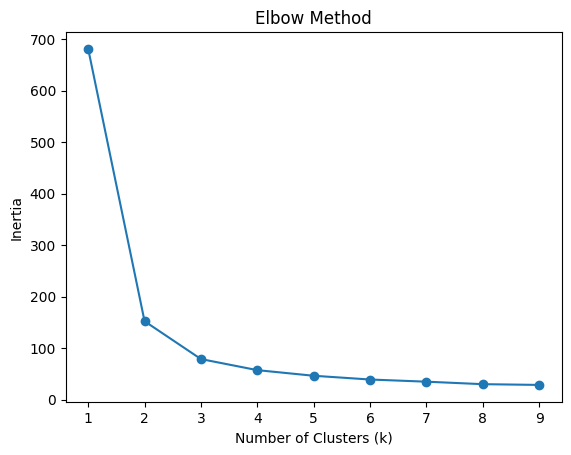

In [14]:
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()